In [3]:
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score
)

from scipy.cluster.hierarchy import (
    linkage,
    dendrogram
)

import umap.umap_ as umap

import matplotlib.pyplot as plt
import seaborn as sns

print("Loading NMF matrices...")

W = np.load(
     "../features/W_nmf.npy"
)

H = np.load(
    "../features/H_nmf.npy"
)

print("W shape:", W.shape)
print("H shape:", H.shape)

notes = pd.read_csv(
    "../features/preprocessed_notes.csv"
)

patient_index = pd.read_csv(
    "../features/patient_index.csv"
)

complexity_df = pd.read_csv(
    "../features/complexity_scores.csv"
)

topic_df = pd.read_csv(
    "../features/patient_topics.csv"
)

feature_names = pd.read_csv(
    "../features/all_feature_names.csv"
)["feature_name"].tolist()

topic_terms = pd.read_csv(
    "../outputs/topic_terms.csv"
)

Loading NMF matrices...
W shape: (10710, 15)
H shape: (15, 10200)


In [4]:
notes = notes.reset_index(drop=True)

notes["complexity_score"] = (
    complexity_df["complexity_score"]
)

notes["dominant_topic"] = (
    topic_df["dominant_topic"]
)

notes["topic_strength"] = (
    topic_df["topic_strength"]
)

print("\nMerged metadata.")


Merged metadata.


In [5]:
print("\nRunning silhouette analysis...")

cluster_range = range(3, 16)

sil_scores = []

for k in cluster_range:

    print(f"Testing k={k}")

    km = KMeans(
        n_clusters=k,
        n_init=20,
        random_state=42
    )

    labels = km.fit_predict(W)

    sil = silhouette_score(
        W,
        labels,
        sample_size=min(5000, len(W))
    )

    sil_scores.append(sil)

    print(f"Silhouette: {sil:.4f}")


Running silhouette analysis...
Testing k=3
Silhouette: 0.2684
Testing k=4
Silhouette: 0.3073
Testing k=5
Silhouette: 0.3225
Testing k=6
Silhouette: 0.3076
Testing k=7
Silhouette: 0.3591
Testing k=8
Silhouette: 0.2537
Testing k=9
Silhouette: 0.3170
Testing k=10
Silhouette: 0.2947
Testing k=11
Silhouette: 0.2623
Testing k=12
Silhouette: 0.2798
Testing k=13
Silhouette: 0.2866
Testing k=14
Silhouette: 0.2874
Testing k=15
Silhouette: 0.2900


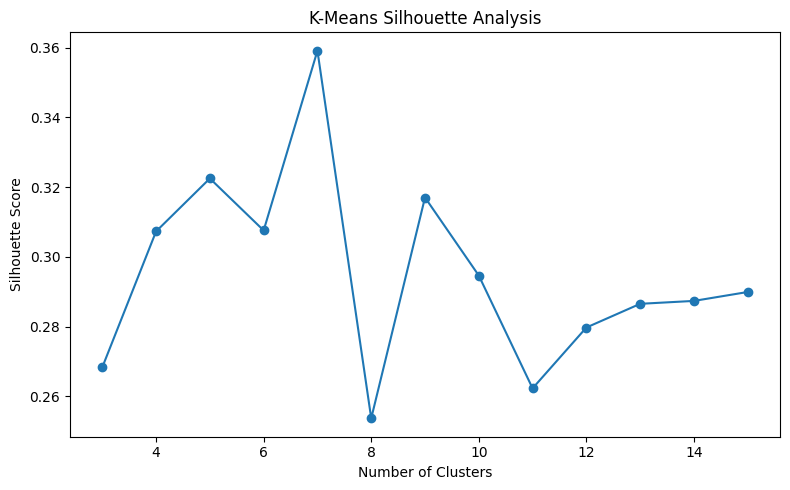


Best K = 7


In [7]:
plt.figure(figsize=(8, 5))

plt.plot(
    list(cluster_range),
    sil_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("K-Means Silhouette Analysis")

plt.tight_layout()

plt.savefig(
    "../outputs/silhouette_curve.png",
    dpi=150
)

plt.show()

BEST_K = list(cluster_range)[
    np.argmax(sil_scores)
]

print(f"\nBest K = {BEST_K}")


In [11]:
print("\nFitting final K-Means...")
kmeans = KMeans(
    n_clusters=BEST_K,
    n_init=30,
    random_state=42
)
notes = notes.iloc[:len(W)].copy()
notes["kmeans_cluster"] = (
    kmeans.fit_predict(W)
)
print("\nK-Means complete.")
cluster_counts = (
    notes["kmeans_cluster"]
    .value_counts()
    .sort_index()
)
print("\n=== CLUSTER COUNTS ===\n")
print(cluster_counts)

dbi = davies_bouldin_score(
    W,
    notes["kmeans_cluster"]
)

print(f"\nDavies-Bouldin Index: {dbi:.4f}")


Fitting final K-Means...

K-Means complete.

=== CLUSTER COUNTS ===

kmeans_cluster
0    7343
1    1699
2     325
3     480
4      97
5     391
6     375
Name: count, dtype: int64

Davies-Bouldin Index: 1.0157



Running hierarchical clustering...


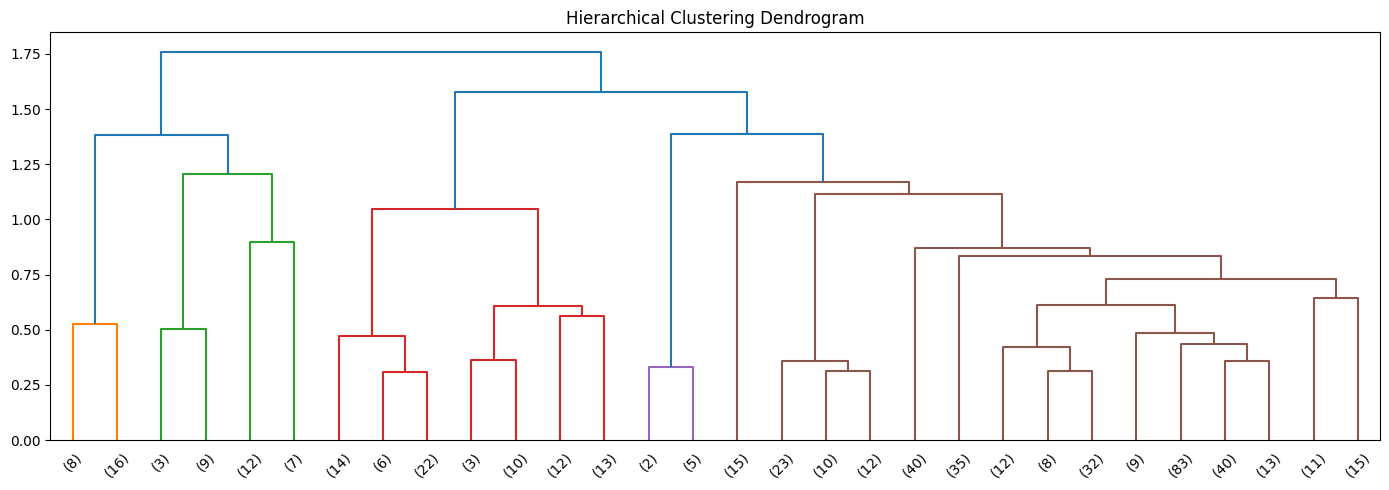

In [12]:
print("\nRunning hierarchical clustering...")
sample_size = min(500, len(W))
sample_idx = np.random.choice(
    len(W),
    sample_size,
    replace=False
)
W_sample = W[sample_idx]
Z = linkage(
    W_sample,
    method="ward"
)
plt.figure(figsize=(14, 5))
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30
)
plt.title("Hierarchical Clustering Dendrogram")
plt.tight_layout()

plt.savefig(
    "../outputs/dendrogram.png",
    dpi=150
)

plt.show()

In [13]:
agg = AgglomerativeClustering(
    n_clusters=BEST_K,
    linkage="ward"
)
notes["agg_cluster"] = (
    agg.fit_predict(W)
)
print("\nAgglomerative clustering complete.")


Agglomerative clustering complete.



Running UMAP...


/mnt/DATA/Projects/Medical_Clustering/.venv311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP complete.


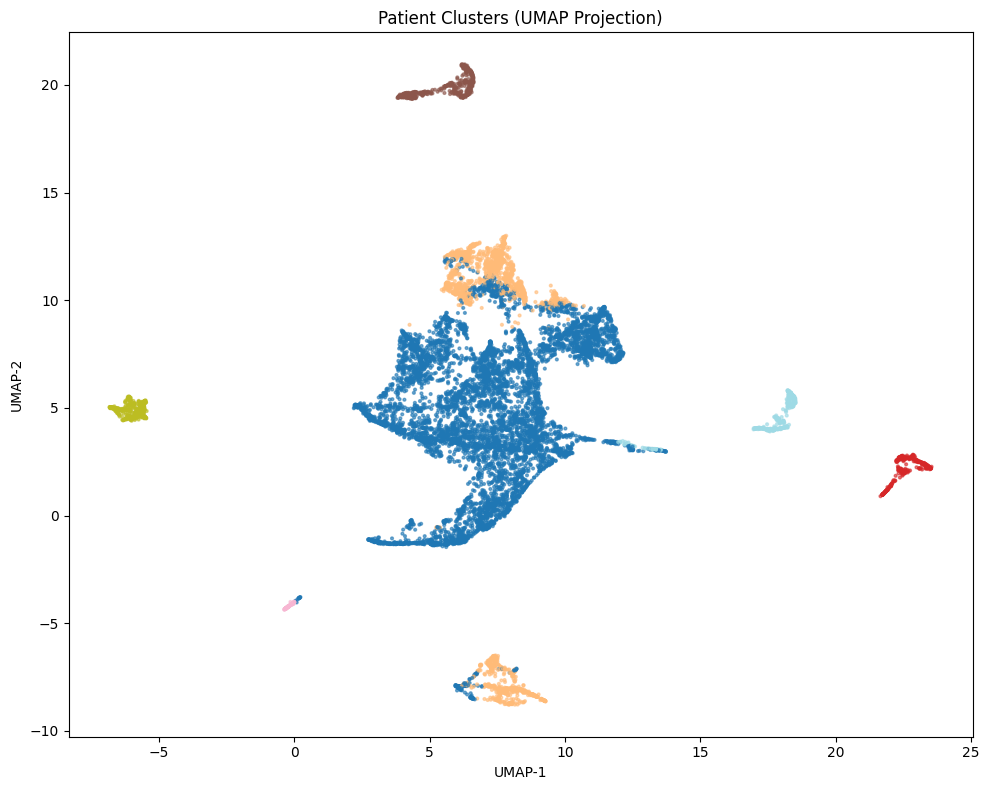

In [14]:
print("\nRunning UMAP...")
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    random_state=42
)
W_2d = reducer.fit_transform(W)
print("UMAP complete.")

umap_df = pd.DataFrame({
    "umap_x": W_2d[:, 0],
    "umap_y": W_2d[:, 1]
})

umap_df.to_csv(
    "../features/umap_coordinates.csv",
    index=False
)

plt.figure(figsize=(10, 8))

scatter = plt.scatter(
    W_2d[:, 0],
    W_2d[:, 1],
    c=notes["kmeans_cluster"],
    cmap="tab20",
    s=4,
    alpha=0.6
)

plt.title("Patient Clusters (UMAP Projection)")

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")

plt.tight_layout()

plt.savefig(
    "../outputs/umap_clusters.png",
    dpi=200
)

plt.show()

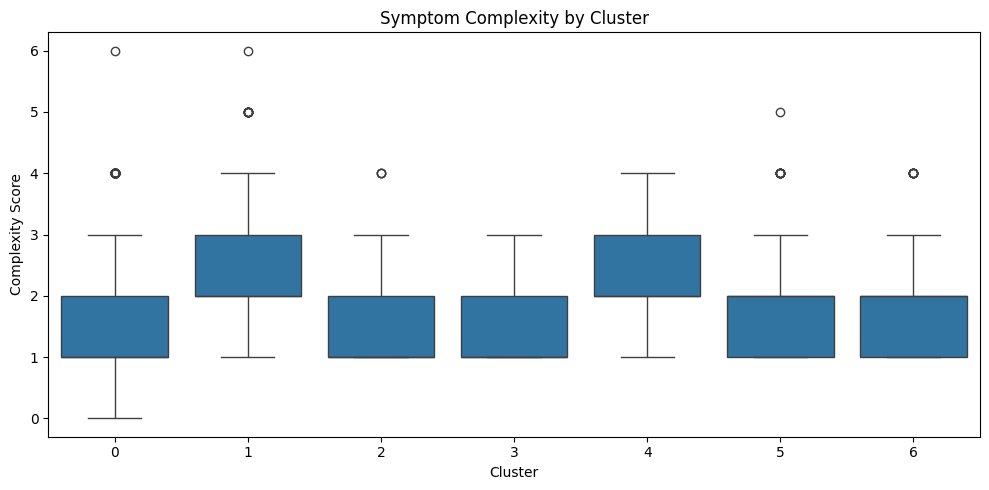

In [15]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=notes,
    x="kmeans_cluster",
    y="complexity_score"
)
plt.xlabel("Cluster")
plt.ylabel("Complexity Score")
plt.title("Symptom Complexity by Cluster")

plt.tight_layout()

plt.savefig(
    "../outputs/complexity_by_cluster.png",
    dpi=150
)

plt.show()

In [16]:
topic_cols = [
    f"topic_{i}"
    for i in range(W.shape[1])
]
topic_matrix = pd.DataFrame(
    W,
    columns=topic_cols
)
topic_matrix["cluster"] = (
    notes["kmeans_cluster"].values
)
cluster_profiles = (
    topic_matrix
    .groupby("cluster")
    .mean()
)
print("\n=== CLUSTER TOPIC PROFILES ===\n")

print(cluster_profiles)


=== CLUSTER TOPIC PROFILES ===

          topic_0   topic_1   topic_2   topic_3   topic_4   topic_5   topic_6  \
cluster                                                                         
0        0.008923  0.002594  0.006397  0.003004  0.004399  0.013090  0.002345   
1        0.028189  0.001147  0.127754  0.003722  0.051178  0.035214  0.001159   
2        0.001710  0.054370  0.000934  0.001348  0.000275  0.004010  0.009310   
3        0.001159  0.067494  0.001271  0.001118  0.000380  0.006756  0.227841   
4        0.018354  0.001235  0.024796  0.385918  0.020386  0.008032  0.000652   
5        0.006473  0.001630  0.013273  0.002170  0.000745  0.012754  0.002489   
6        0.000650  0.101023  0.001032  0.000756  0.000411  0.004993  0.010962   

          topic_7   topic_8   topic_9  topic_10  topic_11  topic_12  topic_13  \
cluster                                                                         
0        0.035202  0.004221  0.023971  0.018697  0.001689  0.023481  0.0284

In [17]:
print("\n=== DOMINANT TOPICS BY CLUSTER ===\n")
for cluster_id in sorted(
    notes["kmeans_cluster"].unique()
):
    row = cluster_profiles.loc[cluster_id]
    top_topics = (
        row.sort_values(ascending=False)
        .head(3)
    )
    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id}")
    print("=" * 80)
    print(top_topics)


=== DOMINANT TOPICS BY CLUSTER ===


CLUSTER 0
topic_7     0.035202
topic_13    0.028499
topic_9     0.023971
Name: 0, dtype: float64

CLUSTER 1
topic_2     0.127754
topic_4     0.051178
topic_10    0.036790
Name: 1, dtype: float64

CLUSTER 2
topic_11    0.242674
topic_1     0.054370
topic_14    0.017454
Name: 2, dtype: float64

CLUSTER 3
topic_6     0.227841
topic_1     0.067494
topic_14    0.015823
Name: 3, dtype: float64

CLUSTER 4
topic_3     0.385918
topic_12    0.044691
topic_2     0.024796
Name: 4, dtype: float64

CLUSTER 5
topic_8     0.218031
topic_12    0.027798
topic_7     0.021430
Name: 5, dtype: float64

CLUSTER 6
topic_14    0.236219
topic_1     0.101023
topic_6     0.010962
Name: 6, dtype: float64


In [18]:
print("\n=== CLUSTER INTERPRETATION ===\n")
for cluster_id in sorted(
    notes["kmeans_cluster"].unique()
):
    row = cluster_profiles.loc[cluster_id]
    dominant_topic_idx = int(
        row.idxmax().split("_")[1]
    )
    topic_terms_subset = (
        topic_terms[
            topic_terms["topic"]
            == dominant_topic_idx
        ]
        .head(10)
    )
    print("\n" + "=" * 80)
    print(f"CLUSTER {cluster_id}")
    print(
        f"\nDominant Topic: "
        f"{dominant_topic_idx}"
    )
    print("\nTop Clinical Terms:\n")
    for _, r in topic_terms_subset.iterrows():
        print(
            f"{r['term']:<40}"
            f"{r['weight']:.4f}"
        )


=== CLUSTER INTERPRETATION ===


CLUSTER 0

Dominant Topic: 7

Top Clinical Terms:

abdominal pain                          1.3221
abdominal                               1.1945
cirrhosis                               1.0105
ascites                                 0.9399
liver                                   0.7838
gi                                      0.7132
abuse                                   0.7131
vomiting                                0.6973
anemia                                  0.6842
pain nausea                             0.6181

CLUSTER 1

Dominant Topic: 2

Top Clinical Terms:

artery                                  2.6425
artery disease                          2.4621
coronary                                2.4404
coronary artery                         2.4129
disease                                 1.0918
hypercholesterolemia                    0.5673
infarction                              0.4602
disease myocardial                      0.4407
myocardial       


=== MORTALITY BY CLUSTER ===

kmeans_cluster
0    0.112399
1    0.102065
2    0.083077
3    0.088235
4    0.072165
5    0.121134
6    0.096257
Name: HOSPITAL_EXPIRE_FLAG, dtype: float64


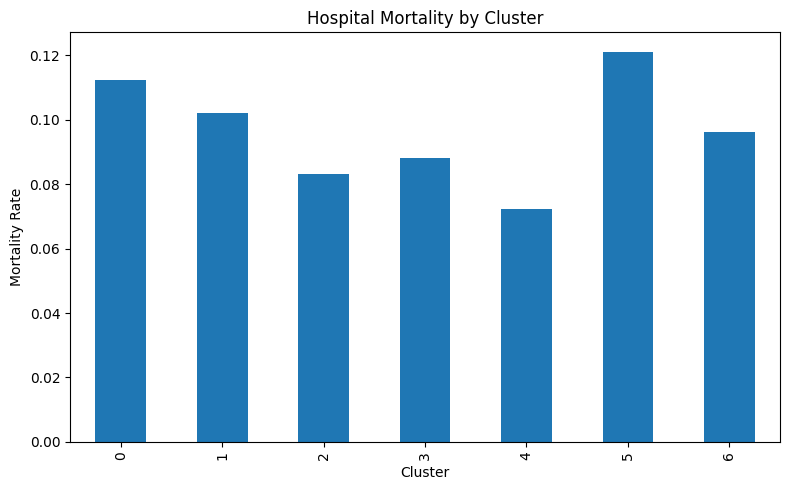

In [20]:
mortality_by_cluster = (
    notes.groupby("kmeans_cluster")
    ["HOSPITAL_EXPIRE_FLAG"]
    .mean()
)
print("\n=== MORTALITY BY CLUSTER ===\n")
print(mortality_by_cluster)
plt.figure(figsize=(8, 5))
mortality_by_cluster.plot(
    kind="bar"
)
plt.ylabel("Mortality Rate")
plt.xlabel("Cluster")
plt.title("Hospital Mortality by Cluster")
plt.tight_layout()
plt.savefig(
    "../outputs/mortality_by_cluster.png",
    dpi=150
)
plt.show()

In [21]:
summary_rows = []
for cluster_id in sorted(
    notes["kmeans_cluster"].unique()
):
    mask = (
        notes["kmeans_cluster"]
        == cluster_id
    )
    row = cluster_profiles.loc[cluster_id]
    dominant_topic_idx = int(
        row.idxmax().split("_")[1]
    )
    topic_terms_subset = (
        topic_terms[
            topic_terms["topic"]
            == dominant_topic_idx
        ]
        .head(5)
    )
    top_terms = ", ".join(
        topic_terms_subset["term"]
    )
    summary_rows.append({
        "cluster": cluster_id,
        "n_patients": mask.sum(),
        "avg_complexity":
            notes.loc[
                mask,
                "complexity_score"
            ].mean(),
        "mortality_rate":
            notes.loc[
                mask,
                "HOSPITAL_EXPIRE_FLAG"
            ].mean(),
        "dominant_topic":
            dominant_topic_idx,
        "top_terms":
            top_terms
    })
cluster_summary = pd.DataFrame(
    summary_rows
)
print("\n=== CLUSTER SUMMARY ===\n")
print(cluster_summary)


=== CLUSTER SUMMARY ===

   cluster  n_patients  avg_complexity  mortality_rate  dominant_topic  \
0        0        7343        1.161923        0.112399               7   
1        1        1699        2.426722        0.102065               2   
2        2         325        1.526154        0.083077              11   
3        3         480        1.554167        0.088235               6   
4        4          97        2.195876        0.072165               3   
5        5         391        1.890026        0.121134               8   
6        6         375        1.733333        0.096257              14   

                                           top_terms  
0  abdominal pain, abdominal, cirrhosis, ascites,...  
1  artery, artery disease, coronary, coronary art...  
2  ICD_96509, respiratory, respiratory distress, ...  
3  ICD_3968, respiratory, respiratory distress, d...  
4  ventricle, left ventricle, thickness, thicknes...  
5  ICD_4280, sepsis, hypotensive, hypotension, se..

In [ ]:
notes.to_csv(
    "../outputs/clustered_patients.csv",
    index=False
)
cluster_summary.to_csv(
    "../outputs/cluster_summary.csv",
    index=False
)
cluster_profiles.to_csv(
    "../outputs/cluster_profiles.csv"
)
print("\nSaved clustering outputs.")


Saved clustering outputs.


In [23]:
print("\n=== FINAL SUMMARY ===\n")
print(f"Patients clustered: {len(notes):,}")
print(f"Number of clusters: {BEST_K}")
print(
    f"Best silhouette score: "
    f"{max(sil_scores):.4f}"
)
print(
    f"Davies-Bouldin score: "
    f"{dbi:.4f}"
)
print("\nClustering complete.")


=== FINAL SUMMARY ===

Patients clustered: 10,710
Number of clusters: 7
Best silhouette score: 0.3591
Davies-Bouldin score: 1.0157

Clustering complete.
